# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Loading and Saving
from moments.saving import get_experiment_paths

data_dir, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

## Moment space discretization

In [8]:
D = 400
Dx, Dz = D + 1, int(np.sqrt(2) * D + 1)

t = np.linspace(0, 2, Dx)
x = t / np.sqrt(2)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

# Ploting

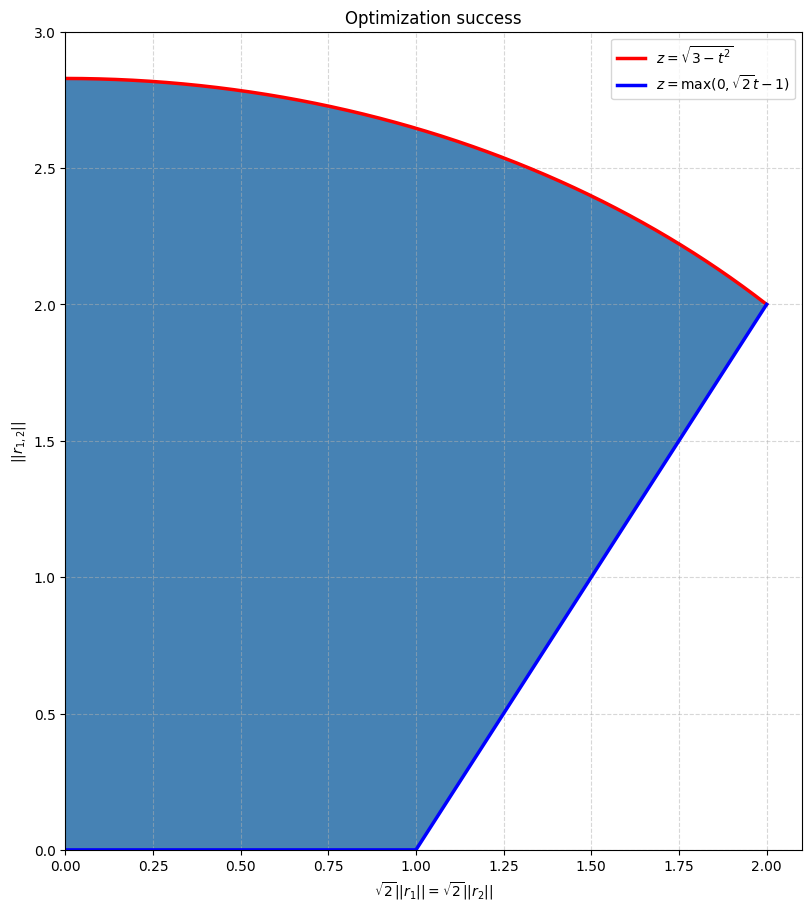

In [9]:
success = np.load(data_dir / "sym_convergence.npy")

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 9), constrained_layout=True)

cmap = plt.cm.colors.ListedColormap(['steelblue'])
cmap.set_bad(color='white')

mesh = ax.pcolormesh(np.sqrt(2) * X, Z, success, shading='auto', cmap=cmap, vmin=0, vmax=1)

ax.set(xlabel=r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel=r"$||r_{1, 2}||$",
       xlim=(0, 2.1), ylim=(0, 3), title="Optimization success")

t = np.linspace(0, 2, 1000)

z_upper = np.sqrt(8 - t**2)
z_lower = np.maximum(0, 2 * (t - 1))

ax.plot(t, z_upper, 'red', linewidth = 2.5, label=r"$z = \sqrt{3 - t^2}$")
ax.plot(t, z_lower, 'blue', linewidth = 2.5, label=r"$z = \max(0, \sqrt{2} t - 1)$")

ax.legend(loc='upper right')
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()